# Outlier Handling

In [1]:
import pandas as pd
titanic_df = pd.read_csv("Updated_Titanic_Data.csv")

# Outlier Handling
# 1. Using IQR (Interquartile Range)

<Axes: >

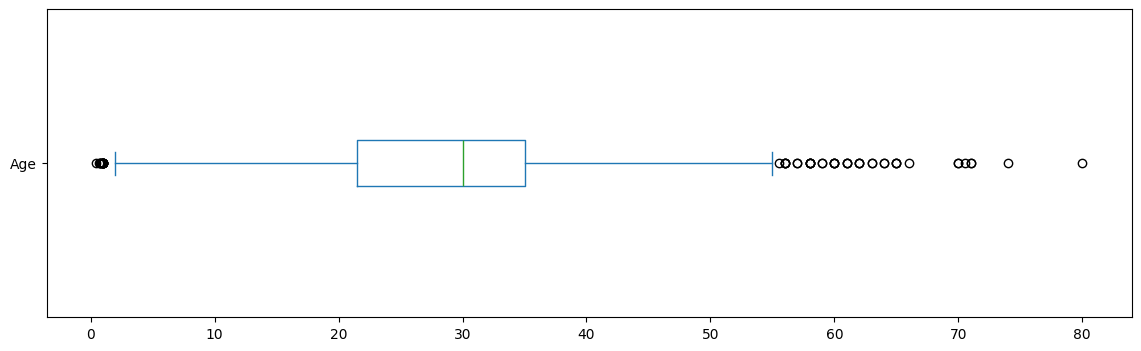

In [2]:
titanic_df.Age.plot(kind="box", vert = False, figsize=(14,4))

In [3]:
q1 = titanic_df.Age.quantile(q = 0.25)
q3 = titanic_df.Age.quantile(q = 0.75)

IQR = q3 - q1

maximum = q3 + (1.5 * IQR)
minimum = q1 - (1.5 * IQR)

# q1, q3, IQR, maximum, minimum


In [4]:
outliers = titanic_df[(titanic_df.Age > maximum) | (titanic_df.Age < minimum)]
outliers.head()

,PassengerId,initials,Survived,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,new_initials,PStatus
11,12.0,Miss,1,"Bonnell, Miss. Elizabeth",female,58.00,0.0,0.0,113783,26.5500,True,S,Miss,1
33,34.0,Mr,0,"Wheadon, Mr. Edward H",male,66.00,0.0,0.0,C.A. 24579,10.5000,False,S,Mr,2
54,55.0,Mr,0,"Ostby, Mr. Engelhart Cornelius",male,65.00,0.0,1.0,113509,61.9792,True,C,Mr,1
77,79.0,Master,1,"Caldwell, Master. Alden Gates",male,0.83,0.0,2.0,248738,29.0000,False,S,Master,2
93,95.0,Mr,0,"Coxon, Mr. Daniel",male,59.00,0.0,0.0,364500,7.2500,False,S,Mr,3


In [5]:
outliers.shape

(53, 14)

In [6]:
# Try Cliping function
titanic_no_outliers_df = titanic_df[(titanic_df.Age <= maximum) & (titanic_df.Age >= minimum)]
titanic_no_outliers_df.head()

,PassengerId,initials,Survived,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,new_initials,PStatus
0,1.0,Mr,0,"Braund, Mr. Owen Harris",male,22.0,1.0,0.0,A/5 21171,7.2500,False,S,Mr,3
1,2.0,Mrs,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1.0,0.0,PC 17599,71.2833,True,C,Mrs,1
2,3.0,Miss,1,"Heikkinen, Miss. Laina",female,26.0,0.0,0.0,STON/O2. 3101282,7.9250,False,S,Miss,3
3,4.0,Mrs,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1.0,0.0,113803,53.1000,True,S,Mrs,1
4,5.0,Mr,0,"Allen, Mr. William Henry",male,35.0,0.0,0.0,373450,8.0500,False,S,Mr,3


In [7]:
len(titanic_no_outliers_df)

836

# 2. Using Z-Score

In [8]:
z_score = abs( 
    (titanic_df.Age - titanic_df.Age.mean()) / titanic_df.Age.std()
)
z_score

0      0.556542
1      0.655345
2      0.253570
3      0.428116
4      0.428116
         ...   
884    0.177827
885    0.783770
886    0.594413
887    0.253570
888    0.200887
Name: Age, Length: 889, dtype: float64

In [9]:
# import scipy
# scipy.stats.zscore(titanic_df.Age)

In [10]:
z_score_filter_df = titanic_df[z_score < 2.698]

In [11]:
z_score_filter_df.head()

,PassengerId,initials,Survived,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,new_initials,PStatus
0,1.0,Mr,0,"Braund, Mr. Owen Harris",male,22.0,1.0,0.0,A/5 21171,7.2500,False,S,Mr,3
1,2.0,Mrs,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1.0,0.0,PC 17599,71.2833,True,C,Mrs,1
2,3.0,Miss,1,"Heikkinen, Miss. Laina",female,26.0,0.0,0.0,STON/O2. 3101282,7.9250,False,S,Miss,3
3,4.0,Mrs,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1.0,0.0,113803,53.1000,True,S,Mrs,1
4,5.0,Mr,0,"Allen, Mr. William Henry",male,35.0,0.0,0.0,373450,8.0500,False,S,Mr,3
